scPred-Py initialized. Remember this is a starting point!
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


/usr/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Applying standard preprocessing...


/home/eva/Class-Project/.venv/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/usr/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Preprocessing finished.
AnnData object with n_obs × n_vars = 2700 × 2933
    obs: 'n_genes', 'cell_type'
    var: 'gene_ids', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg'
Reference data shape: (1889, 2933)
Query data shape: (811, 2933)
Data saved.
AnnData object with n_obs × n_vars = 1889 × 2933
    obs: 'n_genes', 'cell_type'
    var: 'gene_ids', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
Cell types:
 cell_type
0    562
2    327
1    324
3    254
4    242
5    140
6     31
7      9
Name: count, dtype: int64
AnnData object check passed.
--- Starting ScPred Training ---
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier...
Training finished.
--- ScPred Training Complete ---

Model Trained!
PCA Model: PCA(n_components=30, random_state=42)
Classifier: OneVsRestClassifier(estimator=SVC(kernel='linear', probability=True,


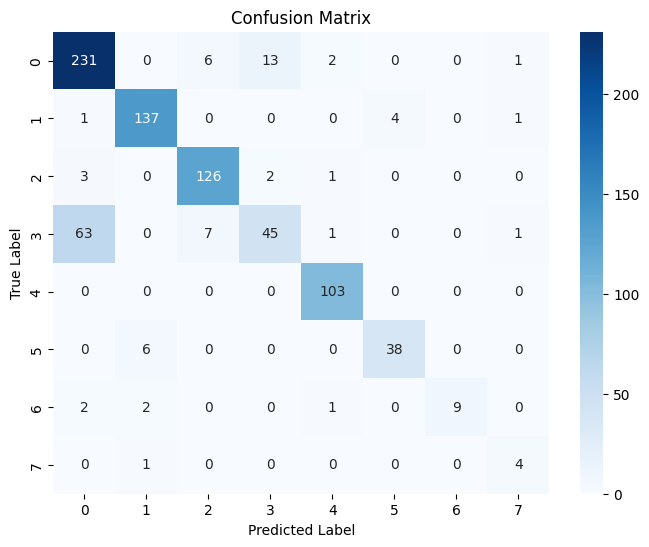

AnnData object check passed.
--- Starting ScPred Prediction ---
AnnData object check passed.
AnnData object check passed.
Found 2933 common genes.
Re-fitting PCA on common genes for projection consistency...
Performing PCA with 30 components...
PCA finished.
Projecting query data onto existing PCA space...
Projection finished.
Predicting cell types...
Prediction finished.
--- ScPred Prediction Complete ---


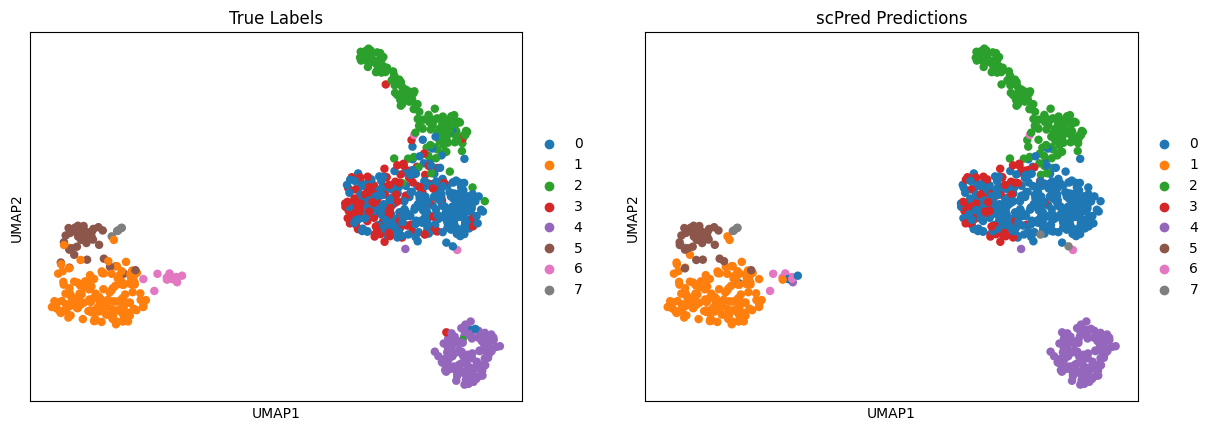

In [1]:
# %% [markdown]
# # 1. Data Loading and Preprocessing
# 
# This notebook loads the PBMC3k dataset, performs standard preprocessing,
# and saves it for later use. We will also split it into a "reference"
# and a "query" set for demonstration purposes.

# %%
import scanpy as sc
import anndata as ad
import numpy as np
import os
import sys

# Add project root to path to import our package
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scpred_py_baseline import _preprocessing

# %% [markdown]
# ## Load Data

# %%
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()
print(adata)

# %% [markdown]
# ## Preprocessing
# 
# We apply standard filtering, normalization, log-transform, HVG selection, and scaling.
# We'll use our custom preprocessing function to keep it consistent.

# %%
# Add some cell type annotations for training (using Scanpy's workflow)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata_hvg = adata[:, adata.var.highly_variable].copy() # Work on HVG subset
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, svd_solver='arpack')
sc.pp.neighbors(adata_hvg, n_neighbors=10, n_pcs=40)
sc.tl.louvain(adata_hvg, random_state=42) # Use louvain clusters as 'cell types'

# Map back the cell types to the full (but preprocessed) data
adata.obs['cell_type'] = adata_hvg.obs['louvain']

# Now apply our *intended* preprocessing (without PCA yet) for scPred
adata_proc = _preprocessing.standard_preprocess(adata.copy())
print(adata_proc)


# %% [markdown]
# ## Split Data (Reference vs. Query)
# 
# We'll randomly split the cells into 70% reference and 30% query.

# %%
n_cells = adata_proc.shape[0]
indices = np.arange(n_cells)
np.random.shuffle(indices)

ref_idx = indices[:int(0.7 * n_cells)]
query_idx = indices[int(0.7 * n_cells):]

ref_adata = adata_proc[ref_idx, :].copy()
query_adata = adata_proc[query_idx, :].copy()

print(f"Reference data shape: {ref_adata.shape}")
print(f"Query data shape: {query_adata.shape}")

# %% [markdown]
# ## Save Data
# 
# We'll save these AnnData objects.

# %%
if not os.path.exists('../data/preprocessed'):
    os.makedirs('../data/preprocessed')

ref_adata.write('../data/preprocessed/baseline_pbmc3k_ref.h5ad')
query_adata.write('../data/preprocessed/baseline_pbmc3k_query.h5ad')

print("Data saved.")

# %% [markdown]
# # 2. Training an scPred Model
# 
# This notebook loads the preprocessed reference data and trains
# our `ScPredModel`.

# %%
import scanpy as sc
import anndata as ad
import numpy as np
import os
import sys
import pickle

# Add project root to path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scpred_py_baseline import ScPredModel

# %% [markdown]
# ## Load Reference Data

# %%
ref_adata = ad.read_h5ad('../data/preprocessed/baseline_pbmc3k_ref.h5ad')
print(ref_adata)
print("Cell types:\n", ref_adata.obs['cell_type'].value_counts())

# %% [markdown]
# ## Initialize and Train the Model
# 
# We use the `ScPredModel` class and train it on our reference data.
# We need to specify which column in `.obs` contains the cell type labels.

# %%
scpred_model = ScPredModel()

# Train the model
scpred_model.train(ref_adata, cell_type_key='cell_type', n_components=30)

print("\nModel Trained!")
print("PCA Model:", scpred_model.pca_model_)
print("Classifier:", scpred_model.classifier_)
print("Reference Genes:", len(scpred_model.reference_genes_))


# %% [markdown]
# ## Save the Trained Model
# 
# We can save the trained model object using `pickle` for later use.

# %%
if not os.path.exists('../models'):
    os.makedirs('../models')

with open('../models/scpred_baseline_model_pbmc3k.pkl', 'wb') as f:
    pickle.dump(scpred_model, f)

print("Trained model saved to ../models/scpred_baseline_model_pbmc3k.pkl")

# %% [markdown]
# # 3. Predicting with an scPred Model
# 
# This notebook loads a trained `ScPredModel` and the query data,
# then performs cell type prediction.

# %%
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import os
import sys
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Add project root to path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# %% [markdown]
# ## Load Model and Query Data

# %%
# Load the trained model
with open('../models/scpred_baseline_model_pbmc3k.pkl', 'rb') as f:
    scpred_model = pickle.load(f)

print("Loaded Model:", scpred_model)

# Load the query data
query_adata = ad.read_h5ad('../data/preprocessed/baseline_pbmc3k_query.h5ad')
print("\nQuery Data:", query_adata)

# %% [markdown]
# ## Perform Prediction
# 
# We use the `predict` method of our loaded model.
# **Important**: The current `_core.py` implementation re-fits PCA
# on common genes and scales the query data. This is a simplification
# and a key area to refine based on the original scPred paper for
# maximum accuracy.

# %%
query_adata_pred = scpred_model.predict(query_adata)

print("\nQuery Data with Predictions:")
print(query_adata_pred.obs[['cell_type', 'scpred_prediction']].head())

# %% [markdown]
# ## Evaluate Predictions
# 
# Since our query data *does* have true labels (because we split it),
# we can evaluate the performance.

# %%
true_labels = query_adata_pred.obs['cell_type']
predicted_labels = query_adata_pred.obs['scpred_prediction']

print("\nClassification Report:\n")
print(classification_report(true_labels, predicted_labels))

# %% [markdown]
# ## Visualize Results
# 
# Let's visualize the confusion matrix.

# %%
cm = confusion_matrix(true_labels, predicted_labels, labels=scpred_model.classifier_.classes_)
cm_df = pd.DataFrame(cm, index=scpred_model.classifier_.classes_, columns=scpred_model.classifier_.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# %% [markdown]
# We can also visualize the UMAP of the query data, colored by true
# and predicted labels.

# %%
# We need to compute UMAP on the query data using its projected PCs
query_adata_pred.obsm['X_scpred_pca'] = scpred_model.predict(query_adata_pred.copy()).obsm['X_scpred_pca'] # Re-run predict to get PCs

# Calculate UMAP based on *our projected* PCs
sc.pp.neighbors(query_adata_pred, n_neighbors=10, use_rep='X_scpred_pca')
sc.tl.umap(query_adata_pred)

# %%
sc.pl.umap(query_adata_pred, color=['cell_type', 'scpred_prediction'], title=['True Labels', 'scPred Predictions'])

# %% [markdown]
# ## Next Steps
# 
# This shows the basic workflow. To improve this, you should focus on:
# 1.  **Hyperparameter Tuning**: Implement `GridSearchCV` in `_training.py`.
# 2.  **PCA Projection Accuracy**: Ensure the scaling and gene handling *exactly* match `scPred`'s method before PCA projection. This might involve saving scaling factors from the reference.
# 3.  **Feature Selection**: Implement the specific informative gene selection used by `scPred`.
# 4.  **Probability Thresholding**: `scPred` includes steps to handle "unassigned" cells based on probability thresholds.
# 5.  **Robustness & Error Handling**: Add more checks and balances.
# 6.  **Testing**: Implement `pytest` tests in the `tests/` directory.